# Titanic Survival Analysis

## Objective
Analyze Titanic passenger data to understand survival patterns based on gender, passenger class, and age group.

## Tools Used
- Python
- Pandas
- Seaborn
- Matplotlib

# Step 1 — Import Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Step 2 — Load Titanic Dataset

In [42]:
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/titanic/train.csv")

# Step 3 — Inspect Dataset

In [43]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


# Step 4 — Check Missing Values

In [44]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


# **Data Cleaning**

# Step 5 — Handle Missing Age Values & Fill Missing Fare

In [47]:
df["Age"] = df["Age"].fillna(df["Age"].median())
df["Fare"] = df["Fare"].fillna(df["Fare"].median())
df.drop(columns=["Cabin"], inplace=True, errors="ignore")
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

# Step 6 — Verify Cleaning

In [48]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


# **Analysis**

# **Q1.Who survived more: males or females?**

In [59]:
survival_gender = (df.groupby("Sex")["Survived"].mean() * 100).round(2)

print("\nSurvival Rate by Gender:\n")
print(survival_gender)

if survival_gender["female"] > survival_gender["male"]:
    print("\nInsight: Females had a higher survival rate than males.")
else:
    print("\nInsight: Males had a higher survival rate than females.")


Survival Rate by Gender:

Sex
female    74.20
male      18.89
Name: Survived, dtype: float64

Insight: Females had a higher survival rate than males.


# **Visualization 1**

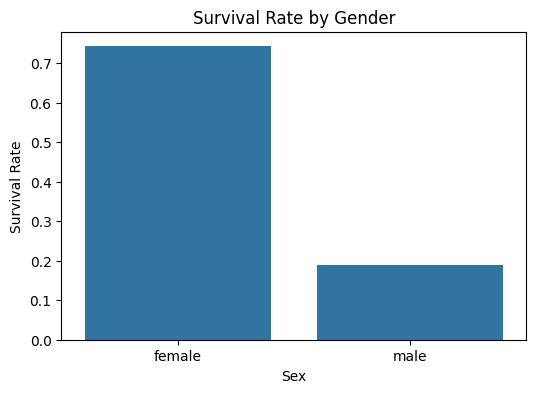

In [60]:
gender_survival = df.groupby("Sex")["Survived"].mean().reset_index()
plt.figure(figsize=(6,4))
sns.barplot(x="Sex", y="Survived", data=gender_survival)
plt.title("Survival Rate by Gender")
plt.ylabel("Survival Rate")

plt.show()

### Insight
Female passengers had significantly higher survival rates compared to male passengers.

# **Q2.Did passenger class affect survival chances?**

In [61]:

class_survival = (df.groupby("Pclass")["Survived"].mean() * 100).round(2)

print("\nSurvival Rate by Passenger Class:\n")
print(class_survival)

highest_class = class_survival.idxmax()

print(f"\nInsight: Passenger Class {highest_class} had the highest survival rate.")


Survival Rate by Passenger Class:

Pclass
1    62.96
2    47.28
3    24.24
Name: Survived, dtype: float64

Insight: Passenger Class 1 had the highest survival rate.


# **Visualization 2**

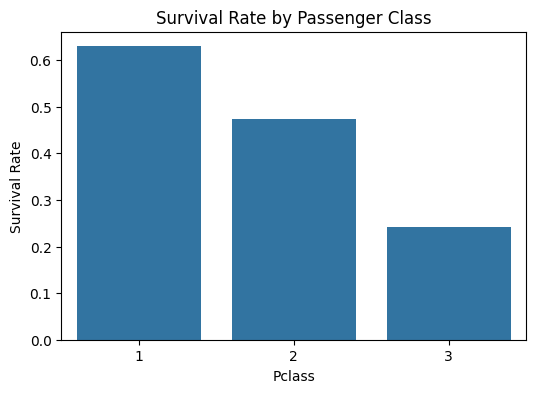

In [62]:
class_survival_chart = df.groupby("Pclass")["Survived"].mean().reset_index()
plt.figure(figsize=(6,4))
sns.barplot(x="Pclass", y="Survived", data=class_survival_chart)
plt.title("Survival Rate by Passenger Class")
plt.ylabel("Survival Rate")

plt.show()


### Insight
First-class passengers had significantly better survival chances compared to second and third-class passengers.

# **Q3.Survival Rate by Age Group**

In [55]:
bins = [0, 12, 19, 35, 60, 100]
labels = ["Child", "Teen", "Young Adult", "Adult", "Senior"]

df["Age_Group"] = pd.cut(df["Age"], bins=bins, labels=labels)

age_survival = (df.groupby("Age_Group", observed=False)["Survived"].mean() * 100).round(2)

print("\nSurvival Rate by Age Group:\n")
print(age_survival)

best_age_group = age_survival.idxmax()

print(f"\nInsight: {best_age_group} passengers had the highest survival rate.")


Survival Rate by Age Group:

Age_Group
Child          57.97
Teen           41.05
Young Adult    35.29
Adult          40.00
Senior         22.73
Name: Survived, dtype: float64

Insight: Child passengers had the highest survival rate.


# **Visualization 3**

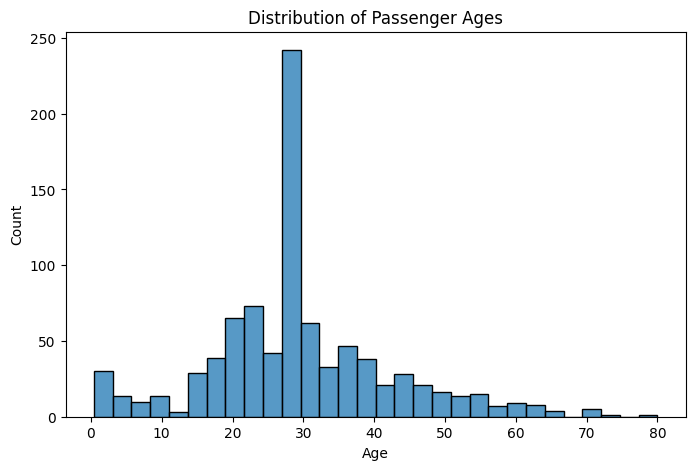

In [54]:
plt.figure(figsize=(8,5))

sns.histplot(df["Age"], bins=30)
plt.title("Distribution of Passenger Ages")
plt.xlabel("Age")

plt.show()

### Insight
Most passengers were young adults between ages 20–40.